In [6]:
! pip install pandas numpy scikit-learn nltk matplotlib seaborn
#nltk.download('stopwords')


'pip' is not recognized as an internal or external command,
operable program or batch file.


In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,roc_curve, roc_auc_score
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
df = pd.read_csv('spam.csv', encoding = 'latin-1')

In [10]:
columns_to_drop = ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')
df
df.info()
df.shape
df.describe()
df.isnull().sum()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   object
 1   v2      5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


Index(['v1', 'v2'], dtype='object')

In [11]:
new_column_names = {'v1': 'Category', 'v2': 'Message'}
df.rename(columns = new_column_names, inplace= True)
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


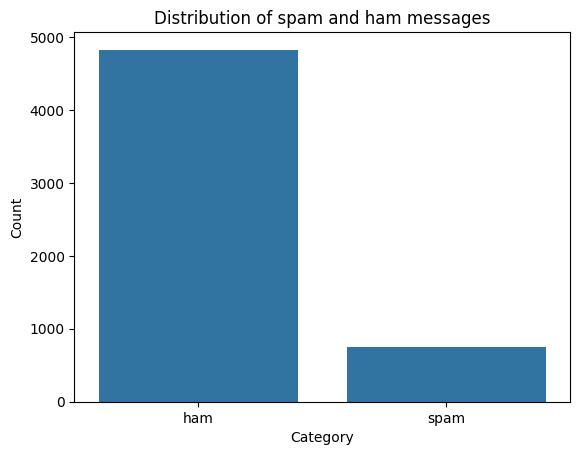

In [12]:
sns.countplot(x='Category', data=df)
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Distribution of spam and ham messages')
plt.show()


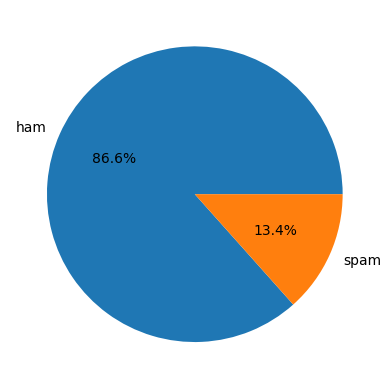

In [13]:
plt.pie(df['Category'].value_counts(), labels=['ham','spam'], autopct='%1.1f%%')
plt.show()

In [15]:
df.loc[df['Category'] == 'ham', 'Category'] = 0
df.loc[df['Category'] == 'spam', 'Category'] = 1
X = df['Message']
Y = df['Category']
print(X)
print(Y)

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                Will Ì_ b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: Message, Length: 5572, dtype: object
0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: Category, Length: 5572, dtype: object


In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)
print(X.shape, X_train.shape, X_test.shape)

(5572,) (4457,) (1115,)


In [18]:
feature_extraction = TfidfVectorizer(min_df=1, stop_words='english', lowercase=True)
X_train_features = feature_extraction.fit_transform(X_train)
X_test_features = feature_extraction.transform(X_test)
Y_train = Y_train.astype('int')
Y_test = Y_test.astype('int')
model = LogisticRegression()
model.fit(X_train_features, Y_train)
predict_train_data= model.predict(X_train_features)
Y_pred = model.predict(X_test_features)
accuracy = accuracy_score(Y_test, Y_pred)
print("Accuracy:", accuracy)
print(X_train_features)
print(X_train)

Accuracy: 0.9524663677130045
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 34794 stored elements and shape (4457, 7472)>
  Coords	Values
  (0, 1371)	0.4658046386365619
  (0, 4416)	0.4528381701109944
  (0, 1706)	0.3431839629173582
  (0, 7415)	0.348722265231364
  (0, 3210)	0.348722265231364
  (0, 4520)	0.4658046386365619
  (1, 1187)	0.26161139982801973
  (1, 3140)	0.3059746053542906
  (1, 3631)	0.2804339696184593
  (1, 6296)	0.269833648032668
  (1, 1533)	0.2015782058421696
  (1, 2661)	0.3059746053542906
  (1, 5005)	0.1937920260229529
  (1, 4292)	0.2953742837684993
  (1, 419)	0.28715203556385105
  (1, 4533)	0.3059746053542906
  (1, 6440)	0.2953742837684993
  (1, 1649)	0.3059746053542906
  (1, 0)	0.2654936554684193
  (2, 3061)	0.44585171875646595
  (2, 5770)	0.3962151014046925
  (2, 1674)	0.35156722029872034
  (2, 5351)	0.5102109014477275
  (2, 2190)	0.5102109014477275
  (3, 5048)	0.4444794309161828
  :	:
  (4451, 5002)	0.36484607066812064
  (4451, 4939)	0.36484607066812064

In [27]:
from sklearn.metrics import accuracy_score,confusion_matrix
predict_train_data=model.predict(X_train_features)
accuracy_train_data=accuracy_score(Y_train,predict_train_data)
print("Accuracy on training data:", accuracy_train_data)
#predict_train_data=model.predict(X_train_features)

Accuracy on training data: 0.9692618353152345


In [25]:
predict_test_data= model.predict(X_test_features)
accuracy_test_data = accuracy_score(Y_test, predict_test_data)
print("Accuracy on test data:", accuracy_test_data)

Accuracy on test data: 0.9524663677130045


In [28]:
new_mail = ["Congratulations on your recent achievement! Well done"]
new_data_features = feature_extraction.transform(new_mail)
prediction= model.predict(new_data_features)
print(prediction)
if(prediction[0] ==1):
    print("Ham mail")
else:
    print("Spam mail")

[0]
Spam mail


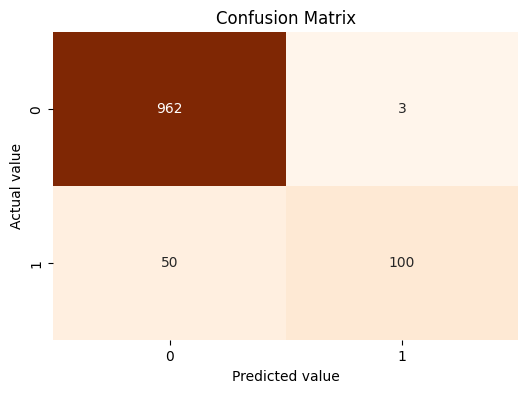

In [31]:
conf_matrix = confusion_matrix(Y_test, predict_test_data)
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix,annot=True,fmt="d",cmap="Oranges",cbar=False)
plt.xlabel("Predicted value")
plt.ylabel("Actual value")
plt.title("Confusion Matrix")
plt.show()

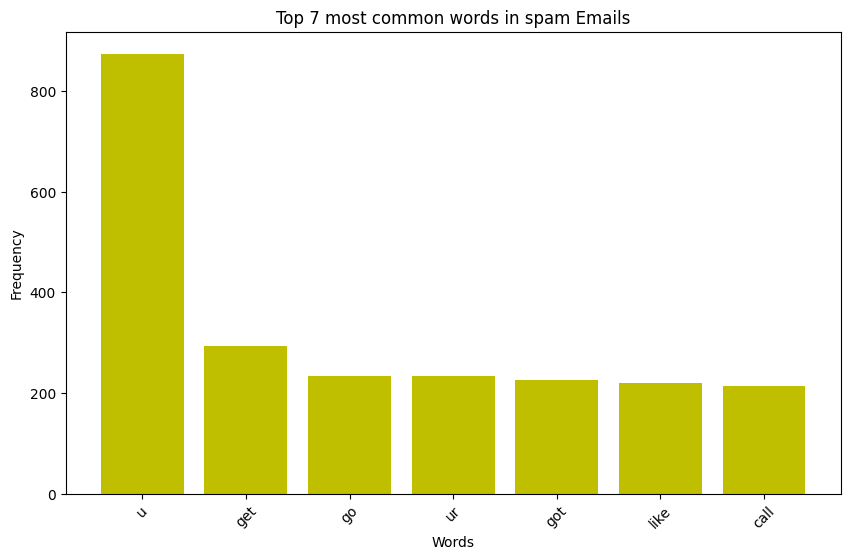

In [34]:
stop_words= set(stopwords.words('english'))
spam_words = " ".join(df[df['Category']==0]['Message']).split()
ham_words = " ".join(df[df['Category']==1]['Message']).split()
spam_word_freq = Counter([words.lower() for words in spam_words if words.lower() not in stop_words
and words.isalpha()])
plt.figure(figsize=(10,6))
plt.bar(*zip(*spam_word_freq.most_common(7)), color='y')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 7 most common words in spam Emails')
plt.xticks(rotation = 45)
plt.show()